# Challenge 20 - Euler's Backward for Stiff Equations

Inference: The backward Euler method will likely be stable for all step sizes h that we test and produce more accurate results as h decreases, which will closelt match the exact solution for very, very small h.

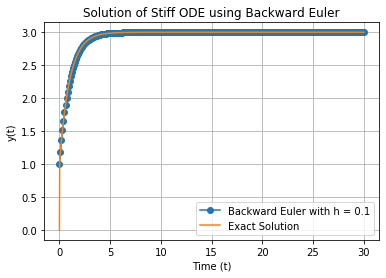

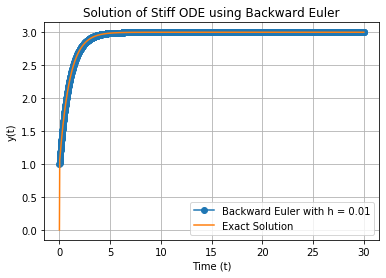

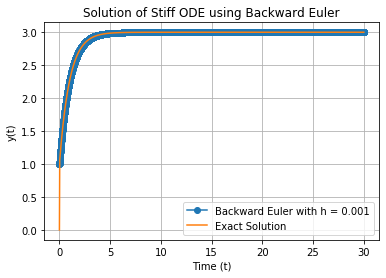

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Define the ODE
def f(t, y):
    return (-1000*y)+3000-2000*np.exp(-t)

# Exact/ Analytical soln
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t) 

# Parameters
y0 = 1
t0 = 0
tf = 30
hvals = [ .1, .01, .001]
t_ex = np.linspace(t0, tf, 1000)


# Backward Euler method
def backward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
        # Implicit function to solve for y_next
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        # Use previous value as initial guess
        y_values[i] = fsolve(g, y_prev)[0]
    
    return t_values, y_values


for h in hvals:
    
    # Solve the ODE
    t_values, y_values = backward_euler(f, y0, t0, tf, h)

    # Plot the results
    plt.plot(t_values, y_values, 'o-', label=f'Backward Euler with h = {h}')
    plt.plot(t_ex, y_exact(t_ex), label=f"Exact Solution")

    plt.xlabel('Time (t)')
    plt.ylabel('y(t)')
    plt.title('Solution of Stiff ODE using Backward Euler')
    plt.legend()
    plt.grid(True)
    plt.show()

Conclusion: Overall, the backward Euler method is effective for solving this stiff equation because it stays stable across all the tested step sizes. The accuracy improves as h decreases, showing convergence toward the exact solution. This illustrates that backward Euler is best for stiff systems, though smaller step sizes are still needed for higher accuracy. It does take longer per step than forward Euler because it's solving an implicit equation at each iteration, whereas forward Euler only evaluates the function directly. While both methods have the same Big O, backward Euler will take slightly longer to compute per step.